1.  Implemente una celda de código que genere como salida los arreglos de entrenamiento y validación del set de datos de prendas de vestir MNIST. Debe transformar el arreglo de datos para añadir el canal de color.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
print('Original shapes:', x_train.shape, y_train.shape, x_test.shape, y_test.shape)


# Añadir canal de color (canal único) -> shape: (N, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
print('After expand_dims:', x_train.shape, x_test.shape)


# Convertir a float32 y normalizar a [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


# Para usar validation_split de forma reproducible se hace un split manual
val_frac = 0.20
val_count = int(len(x_train) * val_frac)


# Mezclar datos primero para buen split
idx = np.arange(len(x_train))
np.random.shuffle(idx)


x_train_all = x_train[idx]
y_train_all = y_train[idx]


x_val = x_train_all[:val_count]
y_val = y_train_all[:val_count]


x_train_final = x_train_all[val_count:]
y_train_final = y_train_all[val_count:]


print('Train/Val/Test shapes:', x_train_final.shape, y_train_final.shape, x_val.shape, y_val.shape, x_test.shape)

Original shapes: (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
After expand_dims: (60000, 28, 28, 1) (10000, 28, 28, 1)
Train/Val/Test shapes: (48000, 28, 28, 1) (48000,) (12000, 28, 28, 1) (12000,) (10000, 28, 28, 1)


2.  Construya un modelo de CNNs utilizando el método facilitado en el cuaderno, luego compílelo con tf.keras.optimizers y los siguientes argumentos:
Optimizador: Adam
Tasa de aprendizaje: 0.001
Función de pérdidas: sparse_categorical_crossentropy
Métrica: accuracy

In [6]:
def create_model(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential(name='Fashion_MNIST_CNN')
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Resizing(28,28)) # redundante pues ya son 28x28, pero seguro
    model.add(layers.Normalization(axis=-1))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


# Crear modelo y adaptar la capa Normalization
model = create_model(input_shape=x_train_final.shape[1:])

# Ajustar la capa Normalization con los datos de entrenamiento
for layer in model.layers:
    if isinstance(layer, layers.Normalization):
        layer.adapt(x_train_final)


# Compilar con Adam lr=0.001, pérdida sparse_categorical_crossentropy, métrica accuracy 
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])


model.summary()

Model: "Fashion_MNIST_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing_1 (Resizing)       (None, 28, 28, 1)         0         
                                                                 
 normalization_1 (Normalizat  (None, 28, 28, 1)        3         
 ion)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 7, 7, 64)   

3.  Entrene el modelo de red neuronal y ejecute su validación usando los datos generados en el primer inciso con los siguientes parámetros:
Resolución de datos: 32-bits en punto flotante (entrenamiento y validación)
Cantidad de épocas: 17
Cantidad de pasos por época: 60

In [8]:
epochs = 17
steps_per_epoch = 60


# Determinar batch_size para aproximar steps_per_epoch cuando se usan arrays
# steps_per_epoch = ceil(len(x_train_final) / batch_size) => batch_size = floor(len / steps_per_epoch)
batch_size = max(1, len(x_train_final) // steps_per_epoch)
print('Calculated batch_size to achieve ~{} steps per epoch: {}'.format(steps_per_epoch, batch_size))


history = model.fit(
                    x_train_final, y_train_final,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(x_val, y_val)
                    )

Calculated batch_size to achieve ~60 steps per epoch: 800
Epoch 1/17
60/60 [==============================] - 1s 13ms/step - loss: 0.1238 - accuracy: 0.9541 - val_loss: 0.2161 - val_accuracy: 0.9218
Epoch 2/17
60/60 [==============================] - 1s 12ms/step - loss: 0.1215 - accuracy: 0.9557 - val_loss: 0.2142 - val_accuracy: 0.9241
Epoch 3/17
60/60 [==============================] - 1s 12ms/step - loss: 0.1083 - accuracy: 0.9595 - val_loss: 0.2180 - val_accuracy: 0.9282
Epoch 4/17
60/60 [==============================] - 1s 12ms/step - loss: 0.1035 - accuracy: 0.9609 - val_loss: 0.2169 - val_accuracy: 0.9244
Epoch 5/17
60/60 [==============================] - 1s 12ms/step - loss: 0.0954 - accuracy: 0.9650 - val_loss: 0.2240 - val_accuracy: 0.9270
Epoch 6/17
60/60 [==============================] - 1s 11ms/step - loss: 0.0905 - accuracy: 0.9662 - val_loss: 0.2396 - val_accuracy: 0.9224
Epoch 7/17
60/60 [==============================] - 1s 11ms/step - loss: 0.0852 - accuracy: 0.96

4. Genere los gráficos relacionados con la función de error y la exactitud tanto en el entrenamiento como en la validación (validation_split=0.20).

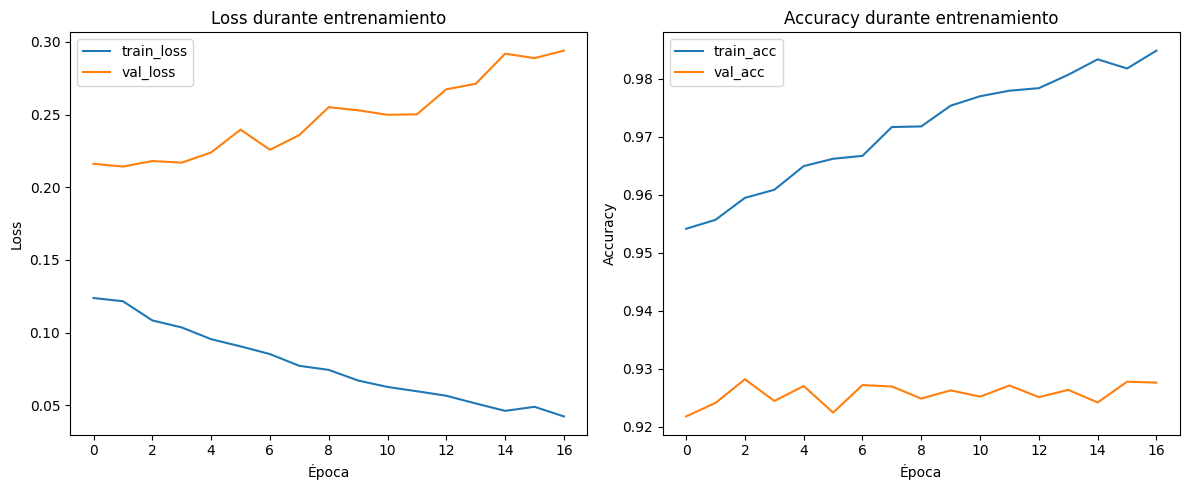

In [9]:
plt.figure(figsize=(12,5))


# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()


# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()

5. Proceda a almacenar en su sesión de Colab los pesos resultantes del entrenamiento en formato .h5 y ejecute el proceso de evaluación del modelo de red neuronal.

In [10]:
output_path = './fashion_mnist_weights.h5'


model.save_weights(output_path)
print('Pesos guardados en:', output_path)


# Evaluación final con el conjunto de prueba
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

Pesos guardados en: ./fashion_mnist_weights.h5
313/313 - 1s - loss: 0.3332 - accuracy: 0.9239 - 1s/epoch - 4ms/step
Test Loss: 0.33317843079566956
Test Accuracy: 0.9239000082015991


6. Opcional: Genere una visualización de las predicciones de prendas de vestir empleado el modelo evaluado.

1/1 [==============================] - 0s 144ms/step


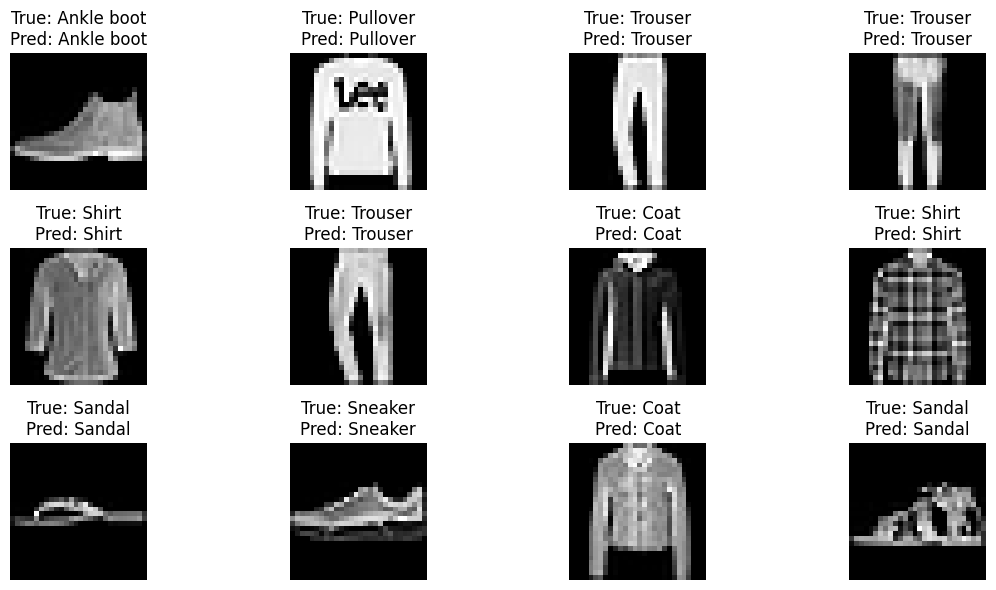

In [12]:
num_show = 12
preds = model.predict(x_test[:num_show])
pred_labels = np.argmax(preds, axis=1)


LABEL_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


plt.figure(figsize=(12,6))
for i in range(num_show):
    plt.subplot(3,4,i+1)
    img = x_test[i].squeeze()
    plt.imshow(img, cmap='gray')
    plt.title(f'True: {LABEL_NAMES[y_test[i]]}\nPred: {LABEL_NAMES[pred_labels[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()